# EDA 16: Repeat Purchase and Retention Analysis

This notebook analyzes repeat purchase behavior, customer retention, inter-order gaps, customer purchase frequency, and leakage-safe retention-related forecast features using `customers.csv`, `orders.csv`, and optional `order_items.csv`.

Findings are exploratory and should be validated before being used for CRM strategy, marketing timing, or forecasting.

## 1. Setup and file discovery

Locate the required and optional CSV files recursively from the current working directory. No EDA outputs are written to disk.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["customers.csv", "orders.csv"]
OPTIONAL_FILES = ["order_items.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    found = {}
    all_csvs = list(root.rglob("*.csv"))
    for filename in filenames:
        target_norm = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target_norm]
        if matches:
            matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
            found[filename] = matches[0]
        else:
            found[filename] = None
    return found

file_paths = find_csv_files(ROOT, ALL_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for req in REQUIRED_FILES:
    if file_paths.get(req) is None:
        display_warning(f"Required file {req} was not found. Sections requiring it will be skipped where necessary.")

for opt in OPTIONAL_FILES:
    if file_paths.get(opt) is None:
        print(f"Note: Optional file {opt} was not found. Revenue context from order items will be skipped.")

,file,path,status
0,customers.csv,D:\Code\Datathon 2026\datathon-2026-round-1\cu...,found
1,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found
2,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found


## 2. Load customers, orders, and optional order_items

Each available CSV is loaded safely with pandas. Basic shape and column information is displayed to support schema validation.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}

load_summary = []
for name, df in data.items():
    if df is None:
        load_summary.append({"file": name, "rows": 0, "columns": 0, "loaded": False})
    else:
        load_summary.append({"file": name, "rows": len(df), "columns": df.shape[1], "loaded": True})
load_summary = pd.DataFrame(load_summary)
display(load_summary)

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

customers = data.get("customers.csv")
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")

,file,rows,columns,loaded
0,customers.csv,121930,7,True
1,orders.csv,646945,8,True
2,order_items.csv,714669,7,True



customers.csv columns:
['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN


## 3. Identify customer, order, date, grouping, and optional revenue columns

Column identification is based on normalized names, common synonyms, date parse quality, and numeric plausibility. If key fields cannot be identified, the notebook displays warnings and skips dependent analysis instead of crashing.

In [3]:
def norm_map(df):
    return {col: normalize_name(col) for col in df.columns} if df is not None else {}

def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        scored.append((score_column(col, include_terms, exclude_terms), col))
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    if scored and scored[0][0] >= min_score:
        return scored[0][1]
    return None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 4), ("time", 3), ("amount", 2), ("price", 2), ("qty", 2), ("quantity", 2)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 4), ("time", 3), ("amount", 2), ("price", 2), ("qty", 2), ("quantity", 2)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(5000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(5000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

def date_parse_score(series):
    parsed = pd.to_datetime(series, errors="coerce")
    valid_rate = parsed.notna().mean()
    unique_count = parsed.nunique(dropna=True)
    return valid_rate, unique_count

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        valid_rate, unique_count = date_parse_score(df[col])
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("created", 5), ("signup", 7), ("registered", 7), ("join", 5), ("order", 5)],
            [("id", 8), ("zip", 7), ("price", 7), ("amount", 7), ("quantity", 7), ("qty", 7)]
        )
        if valid_rate >= 0.5 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col, valid_rate, unique_count))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    exclude_terms = exclude_terms or []
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5:
            continue
        n_unique = numeric.nunique(dropna=True)
        if n_unique < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    if scored and scored[0][0] >= min_score:
        return scored[0][1]
    return None

def choose_revenue_source(orders_df, items_df):
    revenue_terms = [
        ("revenue", 12), ("sales", 10), ("saleamount", 10), ("salesamount", 10),
        ("amount", 8), ("total", 8), ("subtotal", 6), ("net", 6), ("orderamount", 10), ("ordervalue", 10)
    ]
    direct_excludes = [("discount", 10), ("price", 8), ("unit", 4), ("cost", 10), ("cogs", 10), ("quantity", 10), ("qty", 10), ("id", 10)]
    order_direct = choose_numeric_column(orders_df, revenue_terms, direct_excludes, min_score=5)
    if order_direct is not None:
        return {"source": "orders_direct", "column": order_direct}

    if items_df is None:
        return {"source": None}

    item_direct = choose_numeric_column(items_df, revenue_terms, direct_excludes, min_score=5)
    if item_direct is not None:
        return {"source": "items_direct", "column": item_direct}

    qty_col = choose_numeric_column(items_df, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
    price_col = choose_numeric_column(items_df, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
    discount_col = choose_numeric_column(items_df, [("discount", 10), ("promo", 3)], [("id", 5), ("quantity", 8), ("qty", 8)], min_score=5)
    if qty_col is not None and price_col is not None:
        return {"source": "items_inferred", "quantity_col": qty_col, "price_col": price_col, "discount_col": discount_col}
    return {"source": None}

customer_id_terms = [("customerid", 14), ("customer", 8), ("clientid", 12), ("client", 6), ("user", 4), ("buyer", 4)]
order_id_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]

order_customer_col, customer_customer_col = choose_common_key(orders, customers, customer_id_terms)
order_id_col = choose_column_by_terms(orders, order_id_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4) if orders is not None else None
item_order_col, order_item_order_col = choose_common_key(order_items, orders, order_id_terms) if order_items is not None and orders is not None else (None, None)

order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8), ("date", 8)])
signup_date_col = choose_date_column(customers, [("signupdate", 16), ("signup", 12), ("created", 10), ("registered", 10), ("join", 8), ("customer", 4)])

acquisition_col = choose_column_by_terms(
    customers,
    [("acquisitionchannel", 16), ("acquisition", 12), ("channel", 12), ("source", 8), ("campaign", 6), ("medium", 5)],
    [("id", 7), ("date", 7), ("zip", 6)],
    min_score=6,
)

candidate_group_terms = [
    [("segment", 12), ("tier", 7), ("group", 6), ("type", 5)],
    [("region", 12), ("state", 7), ("city", 7), ("country", 6), ("area", 5), ("market", 4)],
    [("agegroup", 12), ("age", 6), ("gender", 6), ("cohort", 4)]
]
grouping_cols = []
if customers is not None:
    for terms in candidate_group_terms:
        col = choose_column_by_terms(customers, terms, [("id", 8), ("date", 8), ("zip", 4)], min_score=5)
        if col is not None and col not in grouping_cols and col != acquisition_col:
            if customers[col].nunique(dropna=True) <= max(50, len(customers) * 0.25):
                grouping_cols.append(col)
    if acquisition_col is not None:
        grouping_cols = [acquisition_col] + grouping_cols

revenue_source = choose_revenue_source(orders, order_items)

detected = pd.DataFrame(
    [
        {"field": "orders.customer_id", "column": order_customer_col},
        {"field": "customers.customer_id", "column": customer_customer_col},
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "orders.order_id_for_items", "column": order_item_order_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "customers.signup_created_date", "column": signup_date_col},
        {"field": "customers.acquisition_channel", "column": acquisition_col},
        {"field": "customer grouping fields", "column": ", ".join(grouping_cols) if grouping_cols else None},
        {"field": "revenue source", "column": str(revenue_source)},
    ]
)
display(detected)

required_ready = True
if customers is None:
    display_warning("customers.csv is unavailable. Customer retention analysis cannot be fully performed.")
    required_ready = False
if orders is None:
    display_warning("orders.csv is unavailable. Customer retention analysis cannot be performed.")
    required_ready = False
if order_customer_col is None or customer_customer_col is None:
    display_warning("Could not identify a usable customer ID join key between orders and customers.")
    required_ready = False
if order_date_col is None:
    display_warning("Could not identify a usable order date column.")
    required_ready = False

if signup_date_col is None:
    print("Note: Customer signup/created date was not identified. First observed order date will be used as a cohort/acquisition proxy.")
if acquisition_col is None:
    print("Note: Acquisition channel was not identified. Group comparisons will use other customer grouping fields if available.")
if revenue_source.get("source") is None:
    print("Note: Order revenue was not identified or inferable. Retention analysis will proceed without revenue context.")

,field,column
0,orders.customer_id,customer_id
1,customers.customer_id,customer_id
2,orders.order_id,order_id
3,order_items.order_id,order_id
4,orders.order_id_for_items,order_id
5,orders.order_date,order_date
6,customers.signup_created_date,signup_date
7,customers.acquisition_channel,acquisition_channel
8,customer grouping fields,"acquisition_channel, age_group, city"
9,revenue source,"{'source': 'items_inferred', 'quantity_col': '..."


## 4. Build customer-order dataset

Orders are joined to customers. Optional order-item revenue is aggregated to order level when identifiable. First observed order date is used as an acquisition/cohort proxy only when signup date is unavailable.

In [4]:
customer_order = pd.DataFrame()
order_revenue = None
item_join_quality = None
used_revenue_context = False
used_signup_proxy = signup_date_col is None

if required_ready:
    orders_work = orders.copy()
    customers_work = customers.copy()

    orders_work["_order_date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
    if order_id_col is not None:
        orders_work["_order_id"] = orders_work[order_id_col].astype(str)
    else:
        orders_work["_order_id"] = np.arange(len(orders_work)).astype(str)
        display_warning("Order ID column was not identified. A row-based order identifier is used only for this EDA.")
    orders_work["_customer_id"] = orders_work[order_customer_col].astype(str)

    customers_work["_customer_id"] = customers_work[customer_customer_col].astype(str)
    if signup_date_col is not None:
        customers_work["_signup_date"] = pd.to_datetime(customers_work[signup_date_col], errors="coerce")
    else:
        customers_work["_signup_date"] = pd.NaT

    if revenue_source.get("source") == "orders_direct":
        order_revenue = orders_work[["_order_id", revenue_source["column"]]].copy()
        order_revenue["revenue"] = pd.to_numeric(order_revenue[revenue_source["column"]], errors="coerce")
        order_revenue = order_revenue.groupby("_order_id", as_index=False)["revenue"].sum(min_count=1)
        used_revenue_context = True
    elif revenue_source.get("source") in ["items_direct", "items_inferred"] and order_items is not None and item_order_col is not None:
        items_work = order_items.copy()
        items_work["_order_id"] = items_work[item_order_col].astype(str)
        if revenue_source.get("source") == "items_direct":
            items_work["item_revenue"] = pd.to_numeric(items_work[revenue_source["column"]], errors="coerce")
        else:
            qty = pd.to_numeric(items_work[revenue_source["quantity_col"]], errors="coerce")
            price = pd.to_numeric(items_work[revenue_source["price_col"]], errors="coerce")
            discount_col = revenue_source.get("discount_col")
            discount = pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) if discount_col is not None else 0
            items_work["item_revenue"] = qty * price
        order_revenue = items_work.groupby("_order_id", as_index=False)["item_revenue"].sum(min_count=1).rename(columns={"item_revenue": "revenue"})
        item_join_quality = {
            "order_items_rows": len(items_work),
            "order_items_matched_to_orders": int(items_work["_order_id"].isin(set(orders_work["_order_id"])).sum()),
            "order_items_unmatched_to_orders": int((~items_work["_order_id"].isin(set(orders_work["_order_id"]))).sum()),
        }
        used_revenue_context = True

    customer_cols = ["_customer_id", "_signup_date"]
    for col in grouping_cols:
        if col in customers_work.columns and col not in customer_cols:
            customer_cols.append(col)

    customer_dim = customers_work[customer_cols].drop_duplicates("_customer_id")
    customer_order = orders_work.merge(customer_dim, on="_customer_id", how="left", indicator="_customer_join")

    if order_revenue is not None:
        customer_order = customer_order.merge(order_revenue, on="_order_id", how="left")

    customer_order = customer_order.dropna(subset=["_order_date"]).copy()
    customer_order = customer_order.sort_values(["_customer_id", "_order_date", "_order_id"])

    first_observed = customer_order.groupby("_customer_id")["_order_date"].min().rename("_first_observed_order_date")
    customer_order = customer_order.merge(first_observed, on="_customer_id", how="left")
    customer_order["_acquisition_date"] = customer_order["_signup_date"]
    customer_order["_acquisition_date"] = customer_order["_acquisition_date"].fillna(customer_order["_first_observed_order_date"])

    keep_cols = ["_customer_id", "_order_id", "_order_date", "_signup_date", "_first_observed_order_date", "_acquisition_date", "_customer_join"]
    keep_cols += [col for col in grouping_cols if col in customer_order.columns]
    if "revenue" in customer_order.columns:
        keep_cols.append("revenue")
    customer_order = customer_order[keep_cols].copy()

    rename_map = {
        "_customer_id": "customer_id",
        "_order_id": "order_id",
        "_order_date": "order_date",
        "_signup_date": "customer_signup_date",
        "_first_observed_order_date": "first_observed_order_date",
        "_acquisition_date": "acquisition_date",
        "_customer_join": "customer_join_status",
    }
    customer_order = customer_order.rename(columns=rename_map)

    if acquisition_col is not None and acquisition_col in customer_order.columns:
        customer_order[acquisition_col] = customer_order[acquisition_col].fillna("Unknown").astype(str)
    for col in grouping_cols:
        if col in customer_order.columns:
            customer_order[col] = customer_order[col].fillna("Unknown").astype(str)

    print(f"Customer-order rows after removing invalid order dates: {len(customer_order):,}")
    display(customer_order.head(10))
else:
    display_warning("Skipping customer-order dataset construction because required fields were not identified.")

Customer-order rows after removing invalid order dates: 646,945


,customer_id,order_id,order_date,customer_signup_date,first_observed_order_date,acquisition_date,customer_join_status,acquisition_channel,age_group,city,revenue
0,1,5280,2012-07-25,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"12,627.3900"
1,1,184922,2014-05-31,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"1,478.7800"
2,1,308113,2015-07-31,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"44,708.3200"
3,1,483190,2017-04-23,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"37,213.4000"
4,1,702081,2020-02-24,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"4,233.3300"
5,1,756884,2021-04-24,2021-12-30,2012-07-25,2021-12-30,both,social_media,35-44,Hai Phong,"42,542.2500"
6,10,13863,2012-08-30,2014-03-03,2012-08-30,2014-03-03,both,organic_search,25-34,Phu Ly,"30,054.2000"
7,10,64035,2013-04-11,2014-03-03,2012-08-30,2014-03-03,both,organic_search,25-34,Phu Ly,"10,087.7400"
8,10,75987,2013-05-12,2014-03-03,2012-08-30,2014-03-03,both,organic_search,25-34,Phu Ly,"12,097.1400"
9,10,243227,2014-12-31,2014-03-03,2012-08-30,2014-03-03,both,organic_search,25-34,Phu Ly,"8,889.8600"


## 5. Join quality checks

Join coverage, duplicate order IDs, and customers without observed orders are checked before interpreting repeat behavior.

In [5]:
join_quality = {}
customers_with_no_orders = np.nan
duplicate_order_count = np.nan

if required_ready and not customer_order.empty:
    matched_orders = int((customer_order["customer_join_status"] == "both").sum())
    unmatched_orders = int((customer_order["customer_join_status"] == "left_only").sum())
    duplicate_order_count = int(customer_order["order_id"].duplicated().sum())

    customer_ids_all = set(customers[customer_customer_col].dropna().astype(str)) if customers is not None else set()
    customer_ids_with_orders = set(customer_order["customer_id"].dropna().astype(str))
    customers_with_no_orders = len(customer_ids_all - customer_ids_with_orders)

    join_quality = {
        "orders_after_valid_dates": len(customer_order),
        "orders_matched_to_customers": matched_orders,
        "orders_unmatched_to_customers": unmatched_orders,
        "duplicate_order_ids_after_join": duplicate_order_count,
        "customers_with_no_orders": customers_with_no_orders,
        "signup_date_available": signup_date_col is not None,
        "cohort_uses_first_order_proxy": used_signup_proxy,
        "revenue_context_available": used_revenue_context,
    }
    if item_join_quality is not None:
        join_quality.update(item_join_quality)

    display(pd.DataFrame([join_quality]).T.rename(columns={0: "value"}))

    if unmatched_orders > 0:
        print("Sample orders unmatched to customers:")
        display(customer_order.loc[customer_order["customer_join_status"] == "left_only", ["order_id", "customer_id", "order_date"]].head(10))
else:
    display_warning("Join quality checks skipped because customer-order data is unavailable.")

,value
orders_after_valid_dates,646945
orders_matched_to_customers,646945
orders_unmatched_to_customers,0
duplicate_order_ids_after_join,0
customers_with_no_orders,31684
signup_date_available,True
cohort_uses_first_order_proxy,False
revenue_context_available,True
order_items_rows,714669
order_items_matched_to_orders,714669


## 6. Repeat purchase summary

Customer-level order counts, first and last observed order dates, lifetime, and repeat-customer flags are calculated. Repeat rates are descriptive and based on observed orders.

,value
customers_in_customer_file,"121,930.0000"
customers_with_observed_orders,"90,246.0000"
customers_with_no_observed_orders,"31,684.0000"
one_time_customers,"22,358.0000"
repeat_customers,"67,888.0000"
repeat_customer_rate_among_ordering_customers,0.7523
one_time_customer_share_among_ordering_customers,0.2477
average_orders_per_customer,7.1687
median_orders_per_customer,4.0000
max_orders_per_customer,107.0000


,orders_per_customer,customers,customer_share
0,1,22358,0.2477
1,2,12460,0.1381
2,3,8352,0.0925
3,4,6216,0.0689
4,5,4936,0.0547
5,6,4154,0.0460
6,7,3516,0.0390
7,8,3044,0.0337
8,9,2673,0.0296
9,10,2313,0.0256


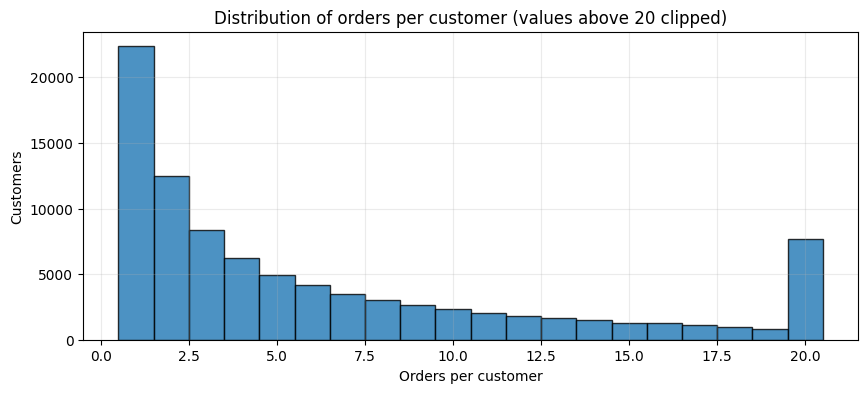

In [6]:
customer_level = pd.DataFrame()
repeat_summary = {}
order_distribution = pd.DataFrame()

if not customer_order.empty:
    customer_order = customer_order.sort_values(["customer_id", "order_date", "order_id"]).copy()
    customer_order["order_sequence"] = customer_order.groupby("customer_id").cumcount() + 1
    customer_order["prev_order_date"] = customer_order.groupby("customer_id")["order_date"].shift(1)
    customer_order["inter_order_gap_days"] = (customer_order["order_date"] - customer_order["prev_order_date"]).dt.days
    customer_order["is_repeat_order"] = customer_order["order_sequence"] > 1

    agg_dict = {
        "order_id": "nunique",
        "order_date": ["min", "max"],
        "customer_signup_date": "first",
        "acquisition_date": "first",
    }
    if "revenue" in customer_order.columns:
        agg_dict["revenue"] = "sum"
    for col in grouping_cols:
        if col in customer_order.columns:
            agg_dict[col] = "first"

    customer_level = customer_order.groupby("customer_id").agg(agg_dict)
    customer_level.columns = [
        "_".join([str(x) for x in col if str(x)]) if isinstance(col, tuple) else str(col)
        for col in customer_level.columns
    ]
    customer_level = customer_level.reset_index()
    customer_level = customer_level.rename(
        columns={
            "order_id_nunique": "orders",
            "order_date_min": "first_order_date",
            "order_date_max": "last_order_date",
            "customer_signup_date_first": "customer_signup_date",
            "acquisition_date_first": "acquisition_date",
            "revenue_sum": "total_revenue",
        }
    )
    grouping_rename_map = {f"{col}_first": col for col in grouping_cols if f"{col}_first" in customer_level.columns}
    if grouping_rename_map:
        customer_level = customer_level.rename(columns=grouping_rename_map)
    customer_level["customer_lifetime_days"] = (customer_level["last_order_date"] - customer_level["first_order_date"]).dt.days
    customer_level["is_repeat_customer"] = customer_level["orders"] > 1
    customer_level["frequency_tier"] = pd.cut(
        customer_level["orders"],
        bins=[0, 1, 3, 5, np.inf],
        labels=["one_time", "2_3_orders", "4_5_orders", "6_plus_orders"],
        include_lowest=True,
    )

    ordering_customers = len(customer_level)
    repeat_customers = int(customer_level["is_repeat_customer"].sum())
    one_time_customers = int((customer_level["orders"] == 1).sum())
    total_customers_file = customers[customer_customer_col].nunique(dropna=True) if customers is not None and customer_customer_col is not None else ordering_customers

    repeat_summary = {
        "customers_in_customer_file": int(total_customers_file),
        "customers_with_observed_orders": ordering_customers,
        "customers_with_no_observed_orders": int(customers_with_no_orders) if not pd.isna(customers_with_no_orders) else np.nan,
        "one_time_customers": one_time_customers,
        "repeat_customers": repeat_customers,
        "repeat_customer_rate_among_ordering_customers": repeat_customers / ordering_customers if ordering_customers else np.nan,
        "one_time_customer_share_among_ordering_customers": one_time_customers / ordering_customers if ordering_customers else np.nan,
        "average_orders_per_customer": customer_level["orders"].mean(),
        "median_orders_per_customer": customer_level["orders"].median(),
        "max_orders_per_customer": customer_level["orders"].max(),
    }
    display(pd.DataFrame([repeat_summary]).T.rename(columns={0: "value"}))

    order_distribution = customer_level["orders"].value_counts().sort_index().rename_axis("orders_per_customer").reset_index(name="customers")
    order_distribution["customer_share"] = order_distribution["customers"] / order_distribution["customers"].sum()
    display(order_distribution.head(20))

    fig, ax = plt.subplots(figsize=(10, 4))
    dist_plot = customer_level["orders"].clip(upper=20)
    ax.hist(dist_plot, bins=np.arange(1, dist_plot.max() + 2) - 0.5, edgecolor="black", alpha=0.8)
    ax.set_title("Distribution of orders per customer (values above 20 clipped)")
    ax.set_xlabel("Orders per customer")
    ax.set_ylabel("Customers")
    plt.show()
else:
    display_warning("Repeat purchase summary skipped because customer-order data is unavailable.")

## 7. Inter-order gap analysis

For customers with at least two orders, this section measures days between consecutive purchases and highlights common repurchase windows.

,value
repeat_order_gap_observations,"556,699.0000"
average_inter_order_gap_days,285.5925
median_inter_order_gap_days,144.0000
p25_inter_order_gap_days,46.0000
p75_inter_order_gap_days,357.0000
min_inter_order_gap_days,0.0000
p99_inter_order_gap_days,"1,898.0000"
max_inter_order_gap_days,"3,785.0000"


,window_days,repeat_orders_within_window,share_of_repeat_orders
0,7,39474,0.0709
1,14,59991,0.1078
2,30,103070,0.1851
3,60,166781,0.2996
4,90,215389,0.3869


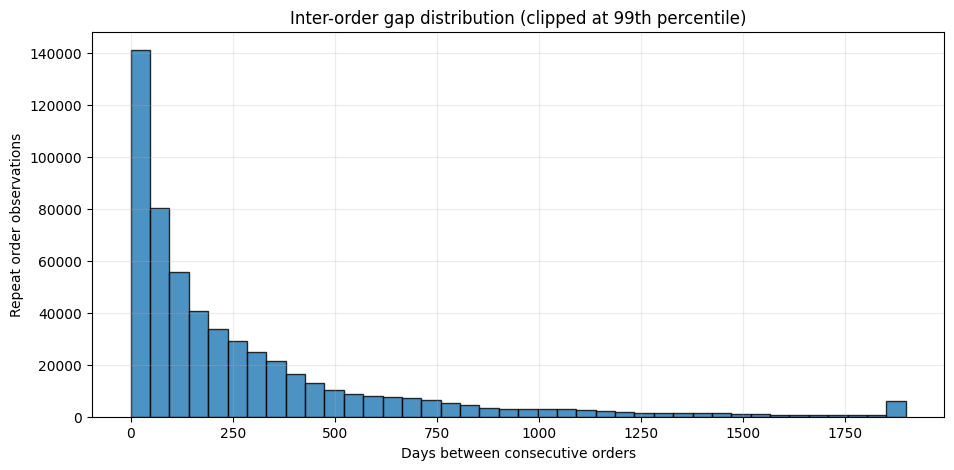

Largest observed inter-order gaps:


,customer_id,order_id,order_date,prev_order_date,inter_order_gap_days
442717,43201,832740,2022-12-21,2012-08-10,"3,785.0000"
344314,20953,831002,2022-11-29,2012-08-01,"3,772.0000"
102944,12480,828611,2022-10-30,2012-08-17,"3,726.0000"
23547,106194,831609,2022-12-06,2012-09-23,"3,726.0000"
152065,134021,827678,2022-10-18,2012-08-07,"3,724.0000"
417385,35745,828342,2022-10-25,2012-08-19,"3,719.0000"
94111,122855,825474,2022-09-27,2012-08-02,"3,708.0000"
128146,130154,828045,2022-10-22,2012-09-02,"3,702.0000"
133113,131338,827070,2022-10-13,2012-08-28,"3,698.0000"
613850,87585,825146,2022-09-22,2012-08-14,"3,691.0000"


In [7]:
gap_data = pd.DataFrame()
gap_summary = {}
repurchase_windows = pd.DataFrame()

if not customer_order.empty and "inter_order_gap_days" in customer_order.columns:
    gap_data = customer_order.loc[customer_order["inter_order_gap_days"].notna()].copy()
    gap_data = gap_data[gap_data["inter_order_gap_days"] >= 0]
    if not gap_data.empty:
        reasonable_gap_limit = gap_data["inter_order_gap_days"].quantile(0.99)
        gap_summary = {
            "repeat_order_gap_observations": len(gap_data),
            "average_inter_order_gap_days": gap_data["inter_order_gap_days"].mean(),
            "median_inter_order_gap_days": gap_data["inter_order_gap_days"].median(),
            "p25_inter_order_gap_days": gap_data["inter_order_gap_days"].quantile(0.25),
            "p75_inter_order_gap_days": gap_data["inter_order_gap_days"].quantile(0.75),
            "min_inter_order_gap_days": gap_data["inter_order_gap_days"].min(),
            "p99_inter_order_gap_days": reasonable_gap_limit,
            "max_inter_order_gap_days": gap_data["inter_order_gap_days"].max(),
        }
        display(pd.DataFrame([gap_summary]).T.rename(columns={0: "value"}))

        windows = [7, 14, 30, 60, 90]
        repurchase_windows = pd.DataFrame(
            {
                "window_days": windows,
                "repeat_orders_within_window": [(gap_data["inter_order_gap_days"] <= w).sum() for w in windows],
                "share_of_repeat_orders": [(gap_data["inter_order_gap_days"] <= w).mean() for w in windows],
            }
        )
        display(repurchase_windows)

        hist_data = gap_data["inter_order_gap_days"].clip(upper=max(1, reasonable_gap_limit))
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.hist(hist_data, bins=40, edgecolor="black", alpha=0.8)
        ax.set_title("Inter-order gap distribution (clipped at 99th percentile)")
        ax.set_xlabel("Days between consecutive orders")
        ax.set_ylabel("Repeat order observations")
        plt.show()

        print("Largest observed inter-order gaps:")
        display(gap_data.sort_values("inter_order_gap_days", ascending=False)[["customer_id", "order_id", "order_date", "prev_order_date", "inter_order_gap_days"]].head(10))
    else:
        display_warning("No repeat order gaps were available after filtering.")
else:
    display_warning("Inter-order gap analysis skipped because repeat order data is unavailable.")

## 8. High-frequency customer groups

Repeat behavior is compared across available grouping fields such as acquisition channel, segment, age group, city, or other customer-level fields. If grouping fields are unavailable, frequency tiers are used.


Repeat behavior by acquisition_channel:


,acquisition_channel,customers,total_orders,avg_orders_per_customer,median_orders_per_customer,repeat_customer_rate,avg_customer_lifetime_days,avg_inter_order_gap_days,total_revenue,revenue_per_customer
2,organic_search,26950,194227,7.2069,4.0000,0.7538,"1,764.9467",284.3506,"4,937,571,851.5700","183,212.3136"
5,social_media,18002,129498,7.1935,4.0000,0.7567,"1,777.5789",287.0056,"3,308,171,218.5100","183,766.8714"
3,paid_search,17999,128953,7.1645,4.0000,0.7502,"1,759.3976",285.4102,"3,271,722,558.1100","181,772.4628"
1,email_campaign,10886,77775,7.1445,4.0000,0.7477,"1,748.4837",284.5609,"1,967,111,032.6700","180,700.9951"
4,referral,9072,64473,7.1068,4.0000,0.7513,"1,752.8893",287.0384,"1,634,969,451.4800","180,221.5004"
0,direct,7337,52019,7.0900,4.0000,0.7484,"1,747.3315",286.9203,"1,310,930,473.1900","178,673.9094"



Repeat behavior by age_group:


,age_group,customers,total_orders,avg_orders_per_customer,median_orders_per_customer,repeat_customer_rate,avg_customer_lifetime_days,avg_inter_order_gap_days,total_revenue,revenue_per_customer
4,55+,10010,72760,7.2687,4.0000,0.7554,"1,777.7521",283.5904,"1,837,522,445.3400","183,568.6759"
3,45-54,17193,124138,7.2203,4.0000,0.7522,"1,772.7374",284.9939,"3,163,670,018.6600","184,009.1909"
2,35-44,23642,170368,7.2062,4.0000,0.7525,"1,762.1112",283.9295,"4,323,232,920.9600","182,862.4025"
1,25-34,26802,190622,7.1122,4.0000,0.7514,"1,753.2734",286.8467,"4,850,426,456.1500","180,972.5564"
0,18-24,12599,89057,7.0686,4.0000,0.7512,"1,751.2519",288.5770,"2,255,624,744.4200","179,032.0458"



Repeat behavior by city:


,city,customers,total_orders,avg_orders_per_customer,median_orders_per_customer,repeat_customer_rate,avg_customer_lifetime_days,avg_inter_order_gap_days,total_revenue,revenue_per_customer
28,Pleiku,969,12674,13.0795,8.0000,0.8173,"2,134.9515",176.7422,"292,164,028.8800","301,510.8657"
41,Vung Tau,975,12097,12.4072,7.0000,0.8041,"2,117.2964",185.6109,"282,708,875.5300","289,957.8211"
5,Buon Ma Thuot,932,11486,12.3240,7.0000,0.8133,"2,135.0258",188.5393,"266,244,920.3700","285,670.5154"
20,Long Xuyen,924,11147,12.0639,6.0000,0.8019,"2,046.6894",184.9888,"263,588,656.0200","285,269.1082"
36,Tra Vinh,844,10113,11.9822,5.0000,0.7595,"1,948.8780",177.4574,"232,848,201.9900","275,886.4952"
1,Bac Lieu,916,10907,11.9072,8.0000,0.8166,"2,146.4290",196.7900,"248,060,537.6200","270,808.4472"
3,Ben Tre,922,10877,11.7972,6.0000,0.8059,"2,073.2798",192.0205,"245,527,398.6300","266,298.6970"
15,Ho Chi Minh City,1054,12395,11.7600,8.0000,0.8036,"2,134.4981",198.3741,"284,484,326.7600","269,909.2284"
40,Vinh Long,951,10920,11.4826,6.0000,0.7865,"1,999.7781",190.7703,"248,301,268.9200","261,094.9200"
32,Soc Trang,923,9970,10.8017,6.0000,0.7757,"1,972.7649",201.2669,"232,096,728.3900","251,459.0773"


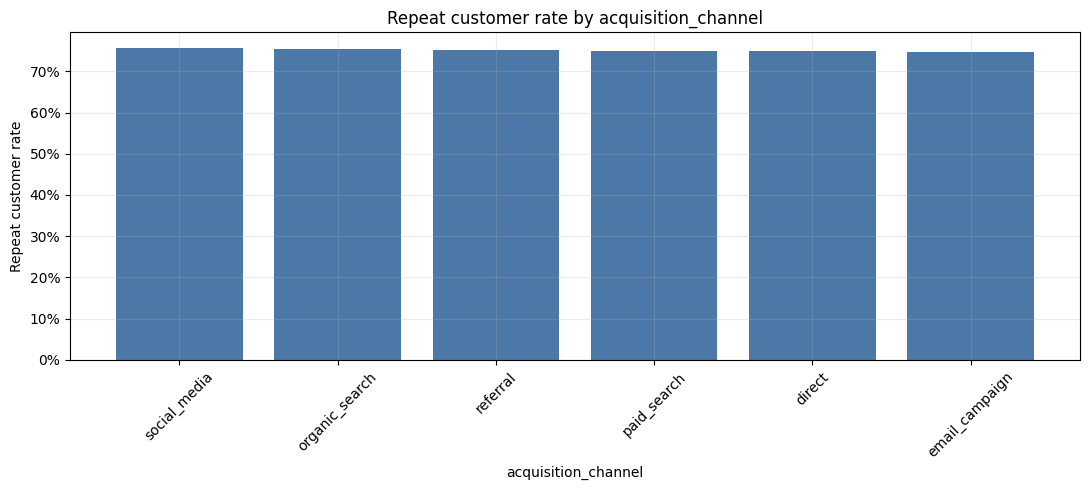

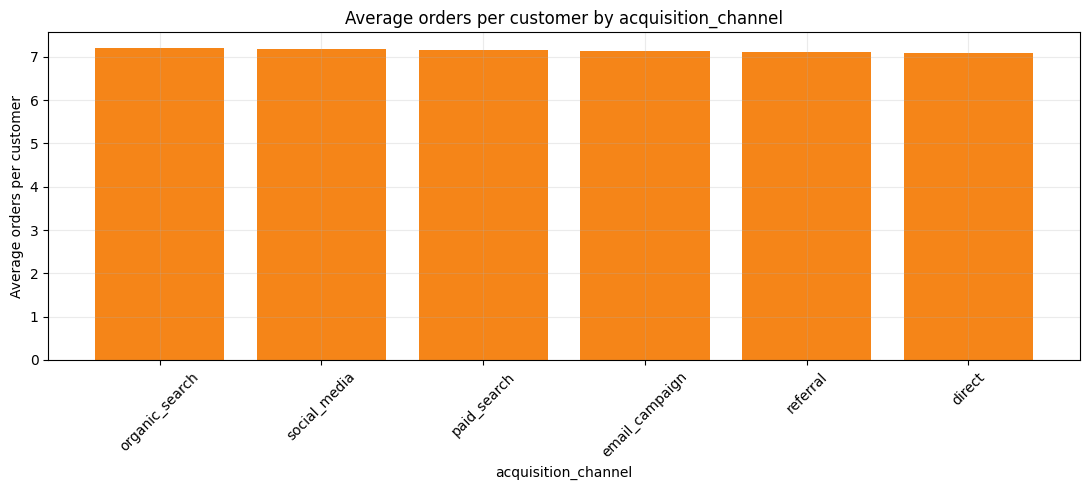

In [8]:
group_summaries = {}
primary_group_summary = pd.DataFrame()

def summarize_group_behavior(df, group_col):
    if df.empty or group_col not in df.columns:
        return pd.DataFrame()
    summary = df.groupby(group_col).agg(
        customers=("customer_id", "nunique"),
        total_orders=("orders", "sum"),
        avg_orders_per_customer=("orders", "mean"),
        median_orders_per_customer=("orders", "median"),
        repeat_customer_rate=("is_repeat_customer", "mean"),
        avg_customer_lifetime_days=("customer_lifetime_days", "mean"),
    ).reset_index()
    if not gap_data.empty and group_col in customer_order.columns:
        gap_group = customer_order.loc[customer_order["inter_order_gap_days"].notna()].groupby(group_col)["inter_order_gap_days"].mean().rename("avg_inter_order_gap_days").reset_index()
        summary = summary.merge(gap_group, on=group_col, how="left")
    else:
        summary["avg_inter_order_gap_days"] = np.nan
    if "total_revenue" in df.columns:
        summary["total_revenue"] = df.groupby(group_col)["total_revenue"].sum().values
        summary["revenue_per_customer"] = summary["total_revenue"] / summary["customers"].replace(0, np.nan)
    return summary.sort_values(["avg_orders_per_customer", "repeat_customer_rate"], ascending=False)

if not customer_level.empty:
    available_group_cols = [col for col in grouping_cols if col in customer_level.columns]
    if available_group_cols:
        for col in available_group_cols:
            summary = summarize_group_behavior(customer_level, col)
            group_summaries[col] = summary
            print(f"\nRepeat behavior by {col}:")
            display(summary.head(20))

        primary_col = available_group_cols[0]
        primary_group_summary = group_summaries[primary_col]

        fig, ax = plt.subplots(figsize=(11, 5))
        plot_df = primary_group_summary.sort_values("repeat_customer_rate", ascending=False).head(15)
        ax.bar(plot_df[primary_col].astype(str), plot_df["repeat_customer_rate"], color="#4C78A8")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title(f"Repeat customer rate by {primary_col}")
        ax.set_xlabel(primary_col)
        ax.set_ylabel("Repeat customer rate")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 5))
        plot_df = primary_group_summary.sort_values("avg_orders_per_customer", ascending=False).head(15)
        ax.bar(plot_df[primary_col].astype(str), plot_df["avg_orders_per_customer"], color="#F58518")
        ax.set_title(f"Average orders per customer by {primary_col}")
        ax.set_xlabel(primary_col)
        ax.set_ylabel("Average orders per customer")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        tier_summary = customer_level.groupby("frequency_tier", observed=False).agg(
            customers=("customer_id", "nunique"),
            avg_orders_per_customer=("orders", "mean"),
            median_orders_per_customer=("orders", "median"),
            repeat_customer_rate=("is_repeat_customer", "mean"),
        ).reset_index()
        display(tier_summary)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(tier_summary["frequency_tier"].astype(str), tier_summary["customers"], color="#54A24B")
        ax.set_title("Customer frequency tiers")
        ax.set_xlabel("Frequency tier")
        ax.set_ylabel("Customers")
        plt.show()
else:
    display_warning("High-frequency group analysis skipped because customer-level data is unavailable.")

## 9. Repeat purchase rate over time

Monthly repeat-order ratio, returning-customer ratio, new customers, and active customers are calculated from observed order history.

,order_month,total_orders,repeat_orders,active_customers,new_customers,returning_customer_orders,returning_customers,repeat_order_ratio,repeat_customer_ratio,new_customer_count
102,2021-01-01,1372,1330,1323,43,1329,"1,281.0000",0.9694,0.9683,42
103,2021-02-01,1976,1902,1889,75,1901,"1,815.0000",0.9626,0.9608,74
104,2021-03-01,4006,3844,3744,165,3841,"3,582.0000",0.9596,0.9567,162
105,2021-04-01,4346,4178,4082,170,4176,"3,914.0000",0.9613,0.9588,168
106,2021-05-01,4267,4081,4006,192,4075,"3,820.0000",0.9564,0.9536,186
107,2021-06-01,3963,3799,3761,165,3798,"3,597.0000",0.9586,0.9564,164
108,2021-07-01,3292,3170,3126,123,3169,"3,004.0000",0.9629,0.9610,122
109,2021-08-01,3225,3103,3068,126,3099,"2,946.0000",0.9622,0.9602,122
110,2021-09-01,2431,2344,2320,88,2343,"2,233.0000",0.9642,0.9625,87
111,2021-10-01,1831,1773,1754,58,1773,"1,696.0000",0.9683,0.9669,58


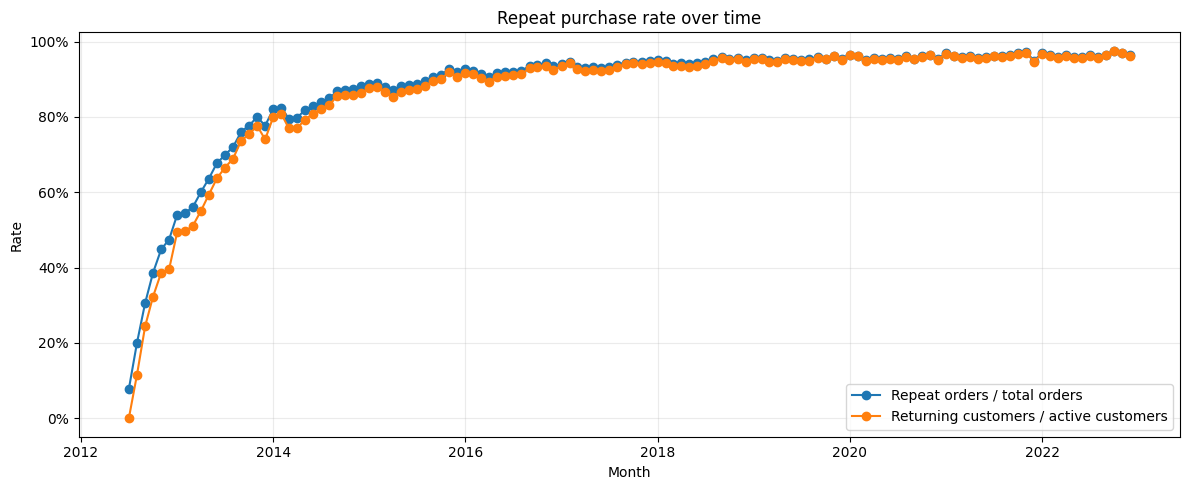

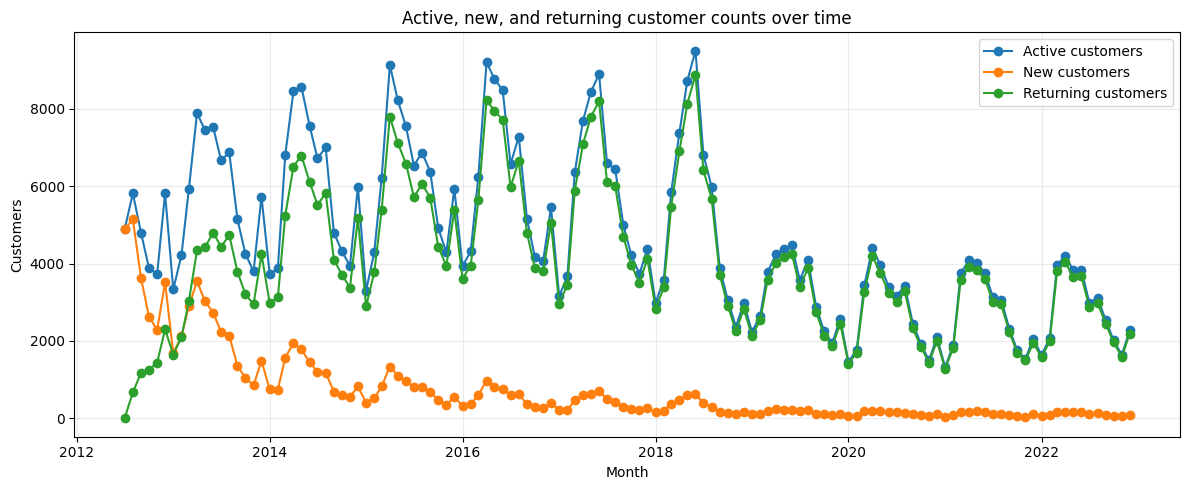

Repeat purchase trend: increasing (last-window average 96.6% vs first-window average 31.6%)


In [9]:
monthly_behavior = pd.DataFrame()
trend_statement = "not enough data to assess"

if not customer_order.empty:
    customer_order["order_month"] = customer_order["order_date"].dt.to_period("M").dt.to_timestamp()
    customer_first_order = customer_order.groupby("customer_id")["order_date"].min().rename("customer_first_order_date")
    time_orders = customer_order.merge(customer_first_order, on="customer_id", how="left")
    time_orders["is_new_customer_order"] = time_orders["order_date"].dt.to_period("M") == time_orders["customer_first_order_date"].dt.to_period("M")
    time_orders["is_returning_customer_order"] = ~time_orders["is_new_customer_order"]

    monthly_behavior = time_orders.groupby("order_month").agg(
        total_orders=("order_id", "nunique"),
        repeat_orders=("is_repeat_order", "sum"),
        active_customers=("customer_id", "nunique"),
        new_customers=("is_new_customer_order", "sum"),
        returning_customer_orders=("is_returning_customer_order", "sum"),
    ).reset_index()
    returning_customers = time_orders.loc[time_orders["is_returning_customer_order"]].groupby("order_month")["customer_id"].nunique().rename("returning_customers")
    monthly_behavior = monthly_behavior.merge(returning_customers, on="order_month", how="left")
    monthly_behavior["returning_customers"] = monthly_behavior["returning_customers"].fillna(0)
    monthly_behavior["repeat_order_ratio"] = monthly_behavior["repeat_orders"] / monthly_behavior["total_orders"].replace(0, np.nan)
    monthly_behavior["repeat_customer_ratio"] = monthly_behavior["returning_customers"] / monthly_behavior["active_customers"].replace(0, np.nan)
    monthly_behavior["new_customer_count"] = time_orders.loc[time_orders["order_sequence"] == 1].groupby("order_month")["customer_id"].nunique().reindex(monthly_behavior["order_month"]).fillna(0).values

    display(monthly_behavior.tail(24))

    if len(monthly_behavior) >= 4:
        first_window = monthly_behavior.head(min(6, len(monthly_behavior)))["repeat_order_ratio"].mean()
        last_window = monthly_behavior.tail(min(6, len(monthly_behavior)))["repeat_order_ratio"].mean()
        diff = last_window - first_window
        if abs(diff) < 0.03:
            trend_statement = "roughly stable"
        elif diff > 0:
            trend_statement = "increasing"
        else:
            trend_statement = "decreasing"
        trend_statement += f" (last-window average {last_window:.1%} vs first-window average {first_window:.1%})"

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_behavior["order_month"], monthly_behavior["repeat_order_ratio"], marker="o", label="Repeat orders / total orders")
    ax.plot(monthly_behavior["order_month"], monthly_behavior["repeat_customer_ratio"], marker="o", label="Returning customers / active customers")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Repeat purchase rate over time")
    ax.set_xlabel("Month")
    ax.set_ylabel("Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_behavior["order_month"], monthly_behavior["active_customers"], marker="o", label="Active customers")
    ax.plot(monthly_behavior["order_month"], monthly_behavior["new_customer_count"], marker="o", label="New customers")
    ax.plot(monthly_behavior["order_month"], monthly_behavior["returning_customers"], marker="o", label="Returning customers")
    ax.set_title("Active, new, and returning customer counts over time")
    ax.set_xlabel("Month")
    ax.set_ylabel("Customers")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Repeat purchase trend: {trend_statement}")
else:
    display_warning("Repeat purchase over-time analysis skipped because customer-order data is unavailable.")

## 10. Cohort retention analysis

Customers are assigned to monthly cohorts using signup date when available, otherwise first observed order month is used as a proxy. Retention rates are calculated by months since cohort month.

Cohort source: customer signup/created date
Cohort retention counts, first 18 months since cohort:


months_since_cohort,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2012-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2012-02,0,0,0,0,0,0,0,3,2,1,3,1,1,0,4,2,2,2
2012-03,0,0,0,0,0,0,2,0,0,1,0,0,1,0,0,3,1,1
2012-04,0,0,0,1,1,1,1,2,1,1,1,2,1,3,2,3,2,2
2012-05,0,0,3,4,5,4,4,1,4,4,2,1,4,6,3,3,1,2
2012-06,0,2,3,6,2,2,2,3,2,6,6,2,2,5,3,1,0,2
2012-07,3,7,4,2,6,7,1,4,2,3,5,6,4,1,2,5,3,3
2012-08,8,2,5,1,2,1,3,2,5,3,4,5,5,7,4,5,5,0
2012-09,6,3,4,6,1,4,6,10,6,9,6,8,4,6,4,7,4,7


Cohort retention rates, first 18 months since cohort:


months_since_cohort,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2012-01,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
2012-02,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,15.8%,10.5%,5.3%,15.8%,5.3%,5.3%,0.0%,21.1%,10.5%,10.5%,10.5%
2012-03,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,13.3%,0.0%,0.0%,6.7%,0.0%,0.0%,6.7%,0.0%,0.0%,20.0%,6.7%,6.7%
2012-04,0.0%,0.0%,0.0%,3.3%,3.3%,3.3%,3.3%,6.7%,3.3%,3.3%,3.3%,6.7%,3.3%,10.0%,6.7%,10.0%,6.7%,6.7%
2012-05,0.0%,0.0%,6.4%,8.5%,10.6%,8.5%,8.5%,2.1%,8.5%,8.5%,4.3%,2.1%,8.5%,12.8%,6.4%,6.4%,2.1%,4.3%
2012-06,0.0%,3.6%,5.5%,10.9%,3.6%,3.6%,3.6%,5.5%,3.6%,10.9%,10.9%,3.6%,3.6%,9.1%,5.5%,1.8%,0.0%,3.6%
2012-07,4.5%,10.6%,6.1%,3.0%,9.1%,10.6%,1.5%,6.1%,3.0%,4.5%,7.6%,9.1%,6.1%,1.5%,3.0%,7.6%,4.5%,4.5%
2012-08,10.5%,2.6%,6.6%,1.3%,2.6%,1.3%,3.9%,2.6%,6.6%,3.9%,5.3%,6.6%,6.6%,9.2%,5.3%,6.6%,6.6%,0.0%
2012-09,6.7%,3.4%,4.5%,6.7%,1.1%,4.5%,6.7%,11.2%,6.7%,10.1%,6.7%,9.0%,4.5%,6.7%,4.5%,7.9%,4.5%,7.9%


Strongest cohort by average retention months 1-6: 2015-02 (9.2% avg months 1-6 retention)
Weakest cohort by average retention months 1-6: 2022-12 (0.0% avg months 1-6 retention)


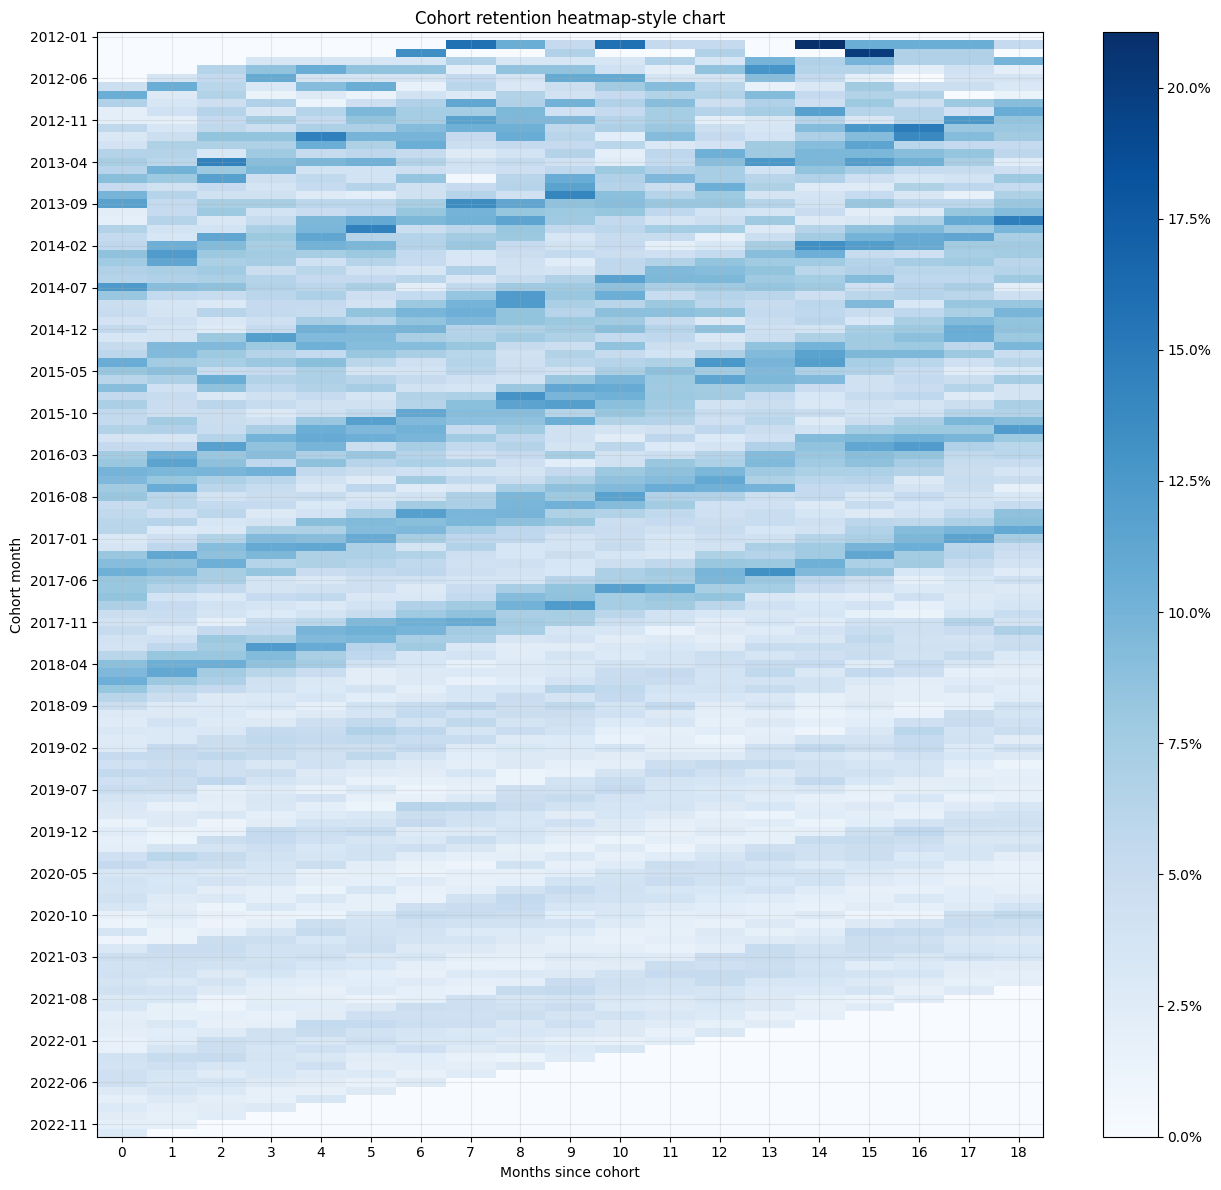

In [10]:
retention_counts = pd.DataFrame()
retention_rates = pd.DataFrame()
cohort_strength = pd.DataFrame()
strongest_cohort = None
weakest_cohort = None

if not customer_order.empty and not customer_level.empty:
    cohort_source = "customer signup/created date" if signup_date_col is not None else "first observed order date proxy"
    cohort_base = customer_level[["customer_id", "acquisition_date"]].copy()
    cohort_base["cohort_month"] = cohort_base["acquisition_date"].dt.to_period("M")
    activity = customer_order[["customer_id", "order_date"]].copy()
    activity["activity_month"] = activity["order_date"].dt.to_period("M")
    activity = activity.drop_duplicates(["customer_id", "activity_month"])
    activity = activity.merge(cohort_base[["customer_id", "cohort_month"]], on="customer_id", how="left")
    activity = activity.dropna(subset=["cohort_month", "activity_month"])
    activity["months_since_cohort"] = (
        (activity["activity_month"].dt.year - activity["cohort_month"].dt.year) * 12
        + (activity["activity_month"].dt.month - activity["cohort_month"].dt.month)
    )
    activity = activity[activity["months_since_cohort"] >= 0].copy()

    retention_counts = activity.pivot_table(
        index="cohort_month",
        columns="months_since_cohort",
        values="customer_id",
        aggfunc="nunique",
        fill_value=0,
    ).sort_index()
    cohort_sizes = cohort_base.groupby("cohort_month")["customer_id"].nunique().sort_index()
    retention_rates = retention_counts.div(cohort_sizes, axis=0)

    print(f"Cohort source: {cohort_source}")
    print("Cohort retention counts, first 18 months since cohort:")
    display(retention_counts.iloc[:, :18].head(20))
    print("Cohort retention rates, first 18 months since cohort:")
    display(retention_rates.iloc[:, :18].head(20).style.format("{:.1%}"))

    post_month_cols = [c for c in retention_rates.columns if 1 <= c <= 6]
    if post_month_cols:
        cohort_strength = retention_rates[post_month_cols].mean(axis=1).rename("avg_retention_months_1_to_6").reset_index()
        cohort_strength["cohort_size"] = cohort_strength["cohort_month"].map(cohort_sizes)
        meaningful = cohort_strength[cohort_strength["cohort_size"] >= max(2, cohort_strength["cohort_size"].median() * 0.25)]
        if not meaningful.empty:
            strongest_row = meaningful.sort_values("avg_retention_months_1_to_6", ascending=False).iloc[0]
            weakest_row = meaningful.sort_values("avg_retention_months_1_to_6", ascending=True).iloc[0]
            strongest_cohort = f"{strongest_row['cohort_month']} ({strongest_row['avg_retention_months_1_to_6']:.1%} avg months 1-6 retention)"
            weakest_cohort = f"{weakest_row['cohort_month']} ({weakest_row['avg_retention_months_1_to_6']:.1%} avg months 1-6 retention)"
            print(f"Strongest cohort by average retention months 1-6: {strongest_cohort}")
            print(f"Weakest cohort by average retention months 1-6: {weakest_cohort}")

    heatmap_cols = [c for c in retention_rates.columns if c <= 18]
    heatmap_df = retention_rates[heatmap_cols].copy()
    if not heatmap_df.empty:
        fig, ax = plt.subplots(figsize=(13, max(5, min(12, len(heatmap_df) * 0.28))))
        image = ax.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=np.nanmax(heatmap_df.values))
        ax.set_title("Cohort retention heatmap-style chart")
        ax.set_xlabel("Months since cohort")
        ax.set_ylabel("Cohort month")
        ax.set_xticks(np.arange(len(heatmap_df.columns)))
        ax.set_xticklabels([str(c) for c in heatmap_df.columns])
        y_positions = np.arange(len(heatmap_df.index))
        max_labels = 30
        if len(y_positions) > max_labels:
            step = int(np.ceil(len(y_positions) / max_labels))
            shown = y_positions[::step]
            ax.set_yticks(shown)
            ax.set_yticklabels([str(heatmap_df.index[i]) for i in shown])
        else:
            ax.set_yticks(y_positions)
            ax.set_yticklabels([str(x) for x in heatmap_df.index])
        cbar = fig.colorbar(image, ax=ax)
        cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        plt.tight_layout()
        plt.show()
else:
    display_warning("Cohort retention analysis skipped because customer-order data is unavailable.")

## 11. Optional retention and revenue context

If order value or revenue is available, revenue is compared across customer frequency tiers. This is supporting context only and does not replace retention metrics.

,frequency_tier,customers,total_orders,total_revenue,avg_revenue_per_customer,median_revenue_per_customer,revenue_per_order
0,one_time,22358,22358,"562,451,605.7600","25,156.6153","17,721.6500","25,156.6153"
1,2_3_orders,20812,49976,"1,230,344,574.6500","59,117.0755","51,012.4800","24,618.7085"
2,4_5_orders,11152,49544,"1,241,637,225.1800","111,337.6278","104,516.4200","25,061.3036"
3,6_plus_orders,35924,525067,"13,396,043,179.9400","372,899.5429","300,873.5900","25,513.0168"


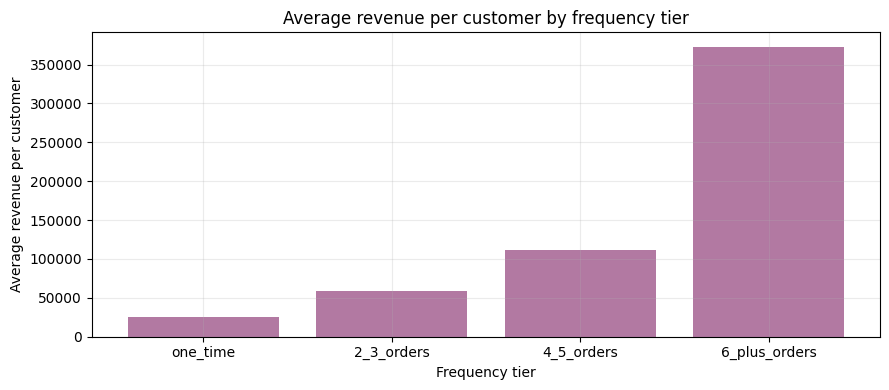

In [11]:
revenue_context = pd.DataFrame()

if not customer_level.empty and "total_revenue" in customer_level.columns and customer_level["total_revenue"].notna().any():
    revenue_context = customer_level.groupby("frequency_tier", observed=False).agg(
        customers=("customer_id", "nunique"),
        total_orders=("orders", "sum"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_customer=("total_revenue", "mean"),
        median_revenue_per_customer=("total_revenue", "median"),
    ).reset_index()
    revenue_context["revenue_per_order"] = revenue_context["total_revenue"] / revenue_context["total_orders"].replace(0, np.nan)
    display(revenue_context)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(revenue_context["frequency_tier"].astype(str), revenue_context["avg_revenue_per_customer"], color="#B279A2")
    ax.set_title("Average revenue per customer by frequency tier")
    ax.set_xlabel("Frequency tier")
    ax.set_ylabel("Average revenue per customer")
    plt.tight_layout()
    plt.show()
else:
    print("Revenue/order value was not available or not inferable. Revenue context is skipped.")

## 12. Leakage-safe retention forecast feature preview

Forecast feature examples use only historical behavior. Daily customer metrics are shifted by one day before lagged and rolling features are computed, so features for date `t` do not use behavior from date `t`.

In [12]:
retention_features = pd.DataFrame()

if not customer_order.empty:
    daily = customer_order.copy()
    daily["date"] = daily["order_date"].dt.floor("D")
    first_order_date_by_customer = customer_order.groupby("customer_id")["order_date"].min().dt.floor("D")
    daily = daily.merge(first_order_date_by_customer.rename("first_order_day"), on="customer_id", how="left")
    daily["is_new_customer_day"] = daily["date"] == daily["first_order_day"]
    daily["is_returning_customer_day"] = ~daily["is_new_customer_day"]

    daily_metrics = daily.groupby("date").agg(
        total_orders=("order_id", "nunique"),
        active_customer_count=("customer_id", "nunique"),
        repeat_orders=("is_repeat_order", "sum"),
        new_customer_count=("is_new_customer_day", "sum"),
        returning_customer_count=("is_returning_customer_day", "sum"),
        avg_inter_order_gap=("inter_order_gap_days", "mean"),
    ).sort_index()
    full_index = pd.date_range(daily_metrics.index.min(), daily_metrics.index.max(), freq="D")
    daily_metrics = daily_metrics.reindex(full_index)
    daily_metrics.index.name = "date"
    count_cols = ["total_orders", "active_customer_count", "repeat_orders", "new_customer_count", "returning_customer_count"]
    daily_metrics[count_cols] = daily_metrics[count_cols].fillna(0)
    daily_metrics["repeat_order_ratio"] = daily_metrics["repeat_orders"] / daily_metrics["total_orders"].replace(0, np.nan)
    daily_metrics["repeat_customer_ratio"] = daily_metrics["returning_customer_count"] / daily_metrics["active_customer_count"].replace(0, np.nan)

    shifted = daily_metrics.shift(1)
    retention_features = pd.DataFrame(index=daily_metrics.index)
    retention_features["total_orders"] = daily_metrics["total_orders"]
    retention_features["active_customer_count_lag"] = shifted["active_customer_count"]
    retention_features["new_customer_count_lag"] = shifted["new_customer_count"]
    retention_features["returning_customer_count_lag"] = shifted["returning_customer_count"]
    retention_features["repeat_order_ratio_lag_30"] = shifted["repeat_orders"].rolling(30, min_periods=7).sum() / shifted["total_orders"].rolling(30, min_periods=7).sum().replace(0, np.nan)
    retention_features["repeat_customer_ratio_lag_30"] = shifted["returning_customer_count"].rolling(30, min_periods=7).sum() / shifted["active_customer_count"].rolling(30, min_periods=7).sum().replace(0, np.nan)
    retention_features["avg_inter_order_gap_lag"] = shifted["avg_inter_order_gap"]
    retention_features["avg_inter_order_gap_roll_mean_30"] = shifted["avg_inter_order_gap"].rolling(30, min_periods=7).mean()
    retention_features["active_customer_count_roll_mean_30"] = shifted["active_customer_count"].rolling(30, min_periods=7).mean()
    retention_features["returning_customer_count_roll_mean_30"] = shifted["returning_customer_count"].rolling(30, min_periods=7).mean()
    retention_features = retention_features.reset_index()

    print("Forecast feature preview. All lagged and rolling retention features are computed after shifting by 1 day.")
    preview = retention_features.dropna(how="all", subset=[c for c in retention_features.columns if c != "date"]).head(20)
    display(preview)
else:
    display_warning("Retention forecast feature preview skipped because customer-order data is unavailable.")

Forecast feature preview. All lagged and rolling retention features are computed after shifting by 1 day.


,date,total_orders,active_customer_count_lag,new_customer_count_lag,returning_customer_count_lag,repeat_order_ratio_lag_30,repeat_customer_ratio_lag_30,avg_inter_order_gap_lag,avg_inter_order_gap_roll_mean_30,active_customer_count_roll_mean_30,returning_customer_count_roll_mean_30
0,2012-07-04,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,97,161.0000,162.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN
2,2012-07-06,93,97.0000,96.0000,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN
3,2012-07-07,73,93.0000,92.0000,1.0000,NaN,NaN,2.0000,NaN,NaN,NaN
4,2012-07-08,88,73.0000,71.0000,2.0000,NaN,NaN,1.5000,NaN,NaN,NaN
5,2012-07-09,137,87.0000,87.0000,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN
6,2012-07-10,183,137.0000,133.0000,4.0000,NaN,NaN,3.0000,NaN,NaN,NaN
7,2012-07-11,221,182.0000,181.0000,2.0000,0.0168,0.0133,1.6667,1.4524,118.5714,1.5714
8,2012-07-12,246,221.0000,212.0000,9.0000,0.0218,0.0190,2.8889,1.6319,131.3750,2.5000
9,2012-07-13,201,243.0000,233.0000,13.0000,0.0300,0.0255,2.3125,1.7076,143.7778,3.6667


## 13. Key observations and warnings

The final summary reports repeat purchase behavior, common repurchase windows, cohort retention, and leakage-safe feature candidates. These are exploratory signals, not causal conclusions.

In [13]:
print("Concise insight summary")
print("=" * 80)

if not repeat_summary:
    print("Repeat purchase summary could not be generated because required customer/order fields were unavailable.")
else:
    repeat_rate = repeat_summary.get("repeat_customer_rate_among_ordering_customers", np.nan)
    one_time_share = repeat_summary.get("one_time_customer_share_among_ordering_customers", np.nan)
    avg_orders = repeat_summary.get("average_orders_per_customer", np.nan)
    med_orders = repeat_summary.get("median_orders_per_customer", np.nan)
    print(f"Repeat customer rate: {repeat_rate:.1%} among customers with observed orders.")
    print(f"One-time customer share: {one_time_share:.1%} among customers with observed orders.")
    print(f"Average / median orders per customer: {avg_orders:.2f} / {med_orders:.2f}.")
    if not pd.isna(customers_with_no_orders):
        print(f"Customers with no observed orders in the available order table: {int(customers_with_no_orders):,}.")

if gap_summary:
    print(
        "Typical inter-order gap: "
        f"mean {gap_summary['average_inter_order_gap_days']:.1f} days, "
        f"median {gap_summary['median_inter_order_gap_days']:.1f} days."
    )
    if not repurchase_windows.empty:
        window_text = ", ".join(
            f"within {int(row.window_days)}d: {row.share_of_repeat_orders:.1%}"
            for row in repurchase_windows.itertuples(index=False)
        )
        print(f"Common repurchase windows: {window_text}.")
else:
    print("Typical inter-order gap: not available because repeat orders were insufficient or missing.")

if not primary_group_summary.empty:
    primary_col = [col for col in grouping_cols if col in primary_group_summary.columns][0]
    high_freq = primary_group_summary.sort_values(["avg_orders_per_customer", "repeat_customer_rate"], ascending=False).head(3)
    group_text = "; ".join(
        f"{getattr(row, primary_col)} ({row.avg_orders_per_customer:.2f} orders/customer, {row.repeat_customer_rate:.1%} repeat rate)"
        for row in high_freq.itertuples(index=False)
    )
    print(f"Customer groups with higher purchase frequency by {primary_col}: {group_text}.")
else:
    print("Customer groups with higher purchase frequency: no usable grouping field was available.")

print(f"Repeat purchase rate over time: {trend_statement}.")

if strongest_cohort and weakest_cohort:
    print(f"Strongest cohort: {strongest_cohort}.")
    print(f"Weakest cohort: {weakest_cohort}.")
else:
    print("Strongest/weakest cohorts: not enough post-cohort retention data to compare reliably.")

if not customer_level.empty:
    tier_counts = customer_level["frequency_tier"].value_counts(dropna=False).sort_index()
    tier_text = ", ".join(f"{idx}: {int(val):,}" for idx, val in tier_counts.items())
    print(f"Customer frequency tiers: {tier_text}.")

if gap_summary:
    median_gap = gap_summary["median_inter_order_gap_days"]
    print(
        "CRM/reminder-campaign implication: the observed median and percentile repurchase windows can guide testable reminder timing, "
        "but they should be validated experimentally before changing campaign policy."
    )
else:
    print("CRM/reminder-campaign implication: insufficient repeat-purchase gaps to suggest timing windows.")

recommended_features = [
    "active_customer_count_lag",
    "new_customer_count_lag",
    "returning_customer_count_lag",
    "repeat_order_ratio_lag_30",
    "repeat_customer_ratio_lag_30",
    "avg_inter_order_gap_lag",
    "avg_inter_order_gap_roll_mean_30",
    "active_customer_count_roll_mean_30",
    "returning_customer_count_roll_mean_30",
]
print("Recommended leakage-safe retention forecast features: " + ", ".join(recommended_features) + ".")
print("Warning: future repeat behavior, future active-customer counts, and future retention outcomes must not be used directly unless separately forecasted.")
print("All forecast feature examples in this notebook shift customer behavior by one day before lagged or rolling calculations.")

Concise insight summary
Repeat customer rate: 75.2% among customers with observed orders.
One-time customer share: 24.8% among customers with observed orders.
Average / median orders per customer: 7.17 / 4.00.
Customers with no observed orders in the available order table: 31,684.
Typical inter-order gap: mean 285.6 days, median 144.0 days.
Common repurchase windows: within 7d: 7.1%, within 14d: 10.8%, within 30d: 18.5%, within 60d: 30.0%, within 90d: 38.7%.
Customer groups with higher purchase frequency by acquisition_channel: organic_search (7.21 orders/customer, 75.4% repeat rate); social_media (7.19 orders/customer, 75.7% repeat rate); paid_search (7.16 orders/customer, 75.0% repeat rate).
Repeat purchase rate over time: increasing (last-window average 96.6% vs first-window average 31.6%).
Strongest cohort: 2015-02 (9.2% avg months 1-6 retention).
Weakest cohort: 2022-12 (0.0% avg months 1-6 retention).
Customer frequency tiers: one_time: 22,358, 2_3_orders: 20,812, 4_5_orders: 11,